# NB03 — Phylogenetic Distribution and Bias Testing

Fisher's exact + BH-FDR phylum enrichment for each category. Pagel's λ using R subprocess. Dual-specialist scatter.

In [1]:
import sys, os, re, warnings, requests, json, subprocess
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy.stats import fisher_exact, norm
from statsmodels.stats.multitest import fdrcorrection
warnings.filterwarnings("ignore")

spark = get_spark_session()
from pyspark.sql import functions as F

NOTEBOOK_DIR = Path().resolve()
PROJECT_DIR  = NOTEBOOK_DIR.parent
DATA_DIR     = PROJECT_DIR / "data"
FIG_DIR      = PROJECT_DIR / "figures"
DATA_DIR.mkdir(exist_ok=True)
FIG_DIR.mkdir(exist_ok=True)

def is_valid_parquet(p):
    if not p.exists() or p.stat().st_size < 512:
        return False
    try:
        import pyarrow.parquet as pq; pq.read_schema(str(p)); return True
    except Exception:
        return False

def wilson_ci(n, N, alpha=0.05):
    if N == 0: return np.nan, np.nan
    p = n / N; z = norm.ppf(1 - alpha/2)
    denom = 1 + z**2/N
    centre = (p + z**2/(2*N)) / denom
    half = z * np.sqrt(p*(1-p)/N + z**2/(4*N**2)) / denom
    return max(0.0, centre - half), min(1.0, centre + half)

def odds_ratio_ci(a, b, c, d, alpha=0.05):
    # Woolf logit OR with 95% CI
    a,b,c,d = a+0.5, b+0.5, c+0.5, d+0.5
    log_or = np.log(a*d/(b*c))
    se = np.sqrt(1/a + 1/b + 1/c + 1/d)
    z = norm.ppf(1 - alpha/2)
    return np.exp(log_or), np.exp(log_or - z*se), np.exp(log_or + z*se)

print("Setup complete.")

Setup complete.


## Section 1 — Load Data

In [2]:
genome_counts = pd.read_parquet(DATA_DIR / "genome_metal_counts.parquet")
print(f"Loaded {len(genome_counts)} genomes")
print(genome_counts.head())

Loaded 27690 genomes
            genome_id                          species          phylum  \
0  GB_GCA_023387895.1         s__Gordonia alkanivorans  Actinomycetota   
1  GB_GCA_900444685.1         s__Achromobacter spanius  Pseudomonadota   
2  RS_GCF_001541345.2           s__Allorhizobium vitis  Pseudomonadota   
3  GB_GCA_018714445.1  s__Fimadaptatus faecigallinarum     Bacillota_A   
4  GB_GCA_020441065.1          s__JACKOY01 sp024233935   Spirochaetota   

                 class          order_rank              family          genus  \
0        Actinomycetia     Mycobacteriales    Mycobacteriaceae       Gordonia   
1  Gammaproteobacteria     Burkholderiales  Burkholderiaceae_C  Achromobacter   
2  Alphaproteobacteria         Rhizobiales        Rhizobiaceae  Allorhizobium   
3           Clostridia  Christensenellales              CAG-74   Fimadaptatus   
4          Leptospirae       Leptospirales     Leptonemataceae       JACKOY01   

   n_defense  n_metabolism  n_homeostasis  n_me

## Section 2 — Phylum Enrichment

Fisher's exact test for enrichment of each category in each phylum. Apply BH-FDR correction.

In [3]:
MAJOR_PHYLA = ['Actinomycetota', 'Pseudomonadota', 'Bacillota', 'Chloroflexota', 'Bacteroidota', 'Cyanobacteriota']
categories = ['defense', 'metabolism', 'homeostasis']

enrichment_rows = []
pvalues = []

for phylum in MAJOR_PHYLA:
    phylum_data = genome_counts[genome_counts['phylum'] == phylum]
    rest_data = genome_counts[genome_counts['phylum'] != phylum]
    
    for category in categories:
        col = f"n_{category}"
        
        # Contingency table: [phylum_has, phylum_not, rest_has, rest_not]
        phylum_has = (phylum_data[col] > 0).sum()
        phylum_not = (phylum_data[col] == 0).sum()
        rest_has = (rest_data[col] > 0).sum()
        rest_not = (rest_data[col] == 0).sum()
        
        oddsratio, pval = fisher_exact([[phylum_has, phylum_not], [rest_has, rest_not]], alternative='two-sided')
        or_est, or_ci_low, or_ci_high = odds_ratio_ci(phylum_has, phylum_not, rest_has, rest_not)
        
        enrichment_rows.append({
            'phylum': phylum,
            'category': category,
            'phylum_has': phylum_has,
            'phylum_not': phylum_not,
            'rest_has': rest_has,
            'rest_not': rest_not,
            'odds_ratio': or_est,
            'or_ci_low': or_ci_low,
            'or_ci_high': or_ci_high,
            'p_value': pval
        })
        pvalues.append(pval)

enrichment_df = pd.DataFrame(enrichment_rows)

# BH-FDR correction — fdrcorrection returns (reject, corrected_pvalues)
reject, q_values = fdrcorrection(enrichment_df['p_value'].values, alpha=0.05)
enrichment_df['q_value'] = q_values
enrichment_df['significant'] = reject

enrichment_df.to_csv(DATA_DIR / "phylum_enrichment.csv", index=False)

print("Significant enrichments (q < 0.05):")
sig = enrichment_df[enrichment_df['significant']]
if len(sig) > 0:
    print(sig[['phylum', 'category', 'odds_ratio', 'or_ci_low', 'or_ci_high', 'q_value']])
else:
    print("None")

Significant enrichments (q < 0.05):
             phylum     category  odds_ratio  or_ci_low   or_ci_high  \
0    Actinomycetota      defense    6.582090   3.191952    13.572857   
1    Actinomycetota   metabolism    1.609514   1.490584     1.737934   
2    Actinomycetota  homeostasis    1.544468   1.345258     1.773178   
3    Pseudomonadota      defense   31.653404  12.491729    80.208110   
4    Pseudomonadota   metabolism    2.921576   2.757640     3.095259   
5    Pseudomonadota  homeostasis   11.006814   9.076712    13.347339   
6         Bacillota      defense    0.653269   0.474988     0.898467   
7         Bacillota   metabolism    0.442271   0.403501     0.484766   
8         Bacillota  homeostasis    1.471241   1.249479     1.732362   
9     Chloroflexota      defense   13.068751   0.814705   209.636896   
11    Chloroflexota  homeostasis    1.432321   1.014769     2.021685   
12     Bacteroidota      defense  117.567688   7.338836  1883.426957   
13     Bacteroidota   metabo

## Section 3 — Forest Plot

Horizontal bar chart showing log2(OR) ± log2(CI) for each phylum per category.

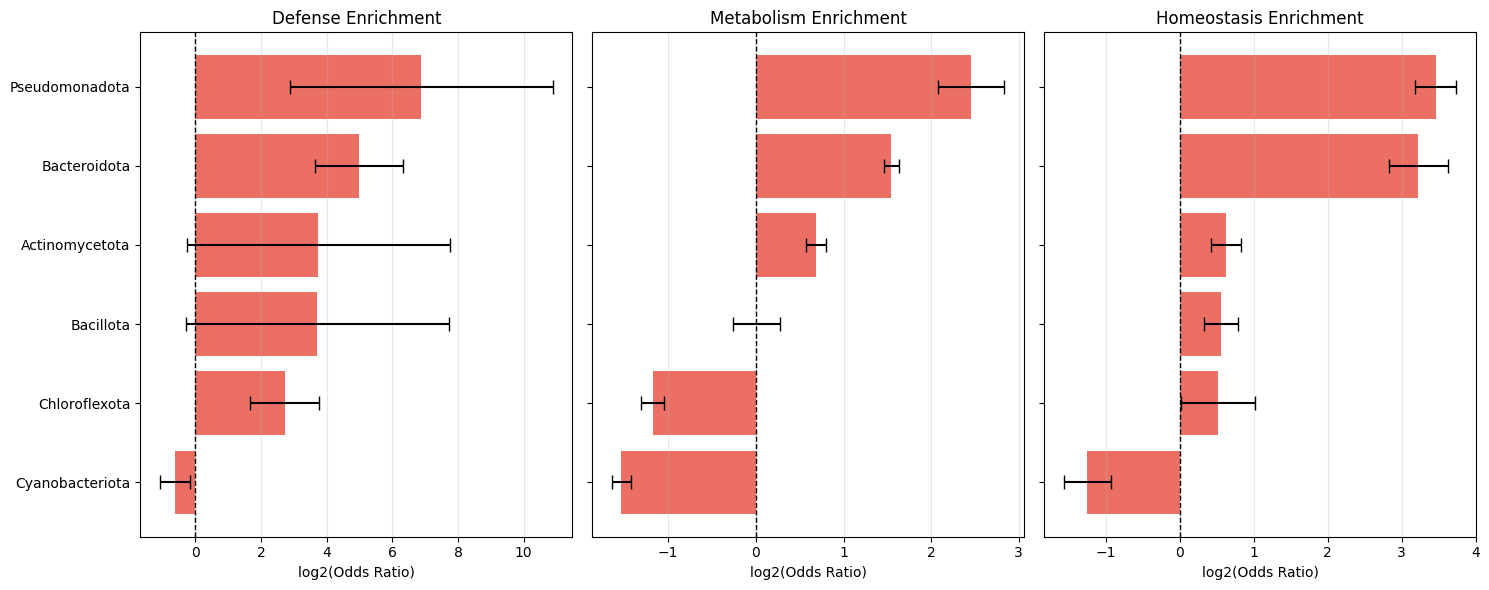

Figure saved: nb03_forest_phylum_enrichment.png


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 6), sharey=True)

for i, category in enumerate(['defense', 'metabolism', 'homeostasis']):
    cat_data = enrichment_df[enrichment_df['category'] == category].copy()
    cat_data = cat_data.sort_values('odds_ratio')
    
    ax = axes[i]
    
    y_pos = np.arange(len(cat_data))
    log2_or = np.log2(cat_data['odds_ratio'].values)
    log2_ci_low = np.log2(cat_data['or_ci_low'].values)
    log2_ci_high = np.log2(cat_data['or_ci_high'].values)
    
    errors = np.array([log2_or - log2_ci_low, log2_ci_high - log2_or])
    
    colors = ['#e74c3c' if q < 0.05 else '#bdc3c7' for q in cat_data['q_value'].values]
    
    ax.barh(y_pos, log2_or, xerr=errors, color=colors, capsize=5, alpha=0.8)
    ax.axvline(x=0, color='black', linestyle='--', linewidth=1)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(cat_data['phylum'].values)
    ax.set_xlabel('log2(Odds Ratio)')
    ax.set_title(f"{category.capitalize()} Enrichment")
    ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig(FIG_DIR / "nb03_forest_phylum_enrichment.png", dpi=300, bbox_inches='tight')
plt.show()

print("Figure saved: nb03_forest_phylum_enrichment.png")

## Section 4 — Pagel's λ

Export species trait matrix and run phylogenetic signal test in R.

In [5]:
# Create binary trait matrix
species_traits = genome_counts.groupby('species').agg({
    'n_defense': 'max',
    'n_metabolism': 'max',
    'n_homeostasis': 'max'
}).reset_index()

species_traits['has_defense'] = (species_traits['n_defense'] > 0).astype(int)
species_traits['has_metabolism'] = (species_traits['n_metabolism'] > 0).astype(int)
species_traits['has_homeostasis'] = (species_traits['n_homeostasis'] > 0).astype(int)

species_traits_export = species_traits[['species', 'has_defense', 'has_metabolism', 'has_homeostasis']]
species_traits_export.to_csv(DATA_DIR / "species_trait_matrix.csv", index=False)

print(f"Species trait matrix: {len(species_traits_export)} species")
print(species_traits_export.head())

Species trait matrix: 27690 species
                          species  has_defense  has_metabolism  \
0  s__0-14-0-80-60-11 sp018897875            1               1   
1  s__0-14-3-00-41-53 sp002780895            1               1   
2   s__01-FULL-36-15b sp001782035            1               1   
3   s__01-FULL-44-24b sp001793235            1               1   
4   s__01-FULL-45-10b sp001804205            1               0   

   has_homeostasis  
0                1  
1                1  
2                0  
3                0  
4                1  


In [6]:
bac_tax = pd.read_csv("/home/hmacgregor/BERIL-research-observatory/projects/microbeatlas_metal_ecology/data/gtdb_bac120_taxonomy_parsed.csv")
arc_tax = pd.read_csv("/home/hmacgregor/BERIL-research-observatory/projects/microbeatlas_metal_ecology/data/gtdb_ar53_taxonomy_parsed.csv")

In [7]:
from Bio import Phylo

all_tax = pd.concat([bac_tax, arc_tax], ignore_index=True)

# Get the set of accession IDs that are actual tips in the tree
bac_tree = Phylo.read('/home/hmacgregor/BERIL-research-observatory/projects/microbeatlas_metal_ecology/data/gtdb_bac120_r214.tree', 'newick')
arc_tree = Phylo.read('/home/hmacgregor/BERIL-research-observatory/projects/microbeatlas_metal_ecology/data/gtdb_ar53_r214.tree', 'newick')
bac_tips = {leaf.name for leaf in bac_tree.get_terminals()}
arc_tips = {leaf.name for leaf in arc_tree.get_terminals()}
all_tips = bac_tips | arc_tips

# Filter taxonomy to only those accessions that are in the tree (i.e., representative genomes)
tax_in_tree = all_tax[all_tax['accession'].isin(all_tips)].copy()

# Create a mapping from species (lowercase) to its representative accession
# GTDB species names are like "s__Gordonia alkanivorans"
species_to_acc = dict(zip(tax_in_tree['gtdb_species'].str.lower(),
                           tax_in_tree['accession']))

In [8]:
# Create a mapping from genome_id to species (using the full taxonomy, not just tree tips)
genome_to_species = dict(zip(all_tax['accession'], all_tax['gtdb_species']))

# Add species from GTDB to genome_counts
genome_counts['gtdb_species'] = genome_counts['genome_id'].map(genome_to_species)

# Now, for each genome, find its representative accession (the one in the tree)
genome_counts['rep_acc'] = genome_counts['gtdb_species'].str.lower().map(species_to_acc)

# Drop rows that have no match in the tree
matched = genome_counts[genome_counts['rep_acc'].notna()].copy()
print(f"Matched {len(matched)} / {len(genome_counts)} genomes to tree tips")

Matched 27690 / 27690 genomes to tree tips


In [9]:
# Aggregate by species (using the GTDB species name)
species_traits = matched.groupby('gtdb_species').agg(
    has_defense    = ('n_defense', lambda x: (x > 0).any().astype(int)),
    has_metabolism = ('n_metabolism', lambda x: (x > 0).any().astype(int)),
    has_homeostasis= ('n_homeostasis', lambda x: (x > 0).any().astype(int)),
    rep_acc        = ('rep_acc', 'first')   # all rows in a species have the same rep_acc
).reset_index()

# Also keep the representative accession for pruning
species_traits['species_lower'] = species_traits['gtdb_species'].str.lower()

In [10]:
def prune_tree_to_accessions(tree_path, accessions, output_path):
    tree = Phylo.read(tree_path, 'newick')
    keep = set(accessions)
    # Remove tips not in keep
    to_remove = [t for t in tree.get_terminals() if t.name not in keep]
    for t in to_remove:
        tree.prune(t)
    # Relabel tips to species names (optional but convenient)
    name_map = dict(zip(species_traits['rep_acc'], species_traits['gtdb_species']))
    for t in tree.get_terminals():
        t.name = name_map.get(t.name, t.name)
    Phylo.write(tree, output_path, 'newick')
    print(f"Pruned tree with {len(tree.get_terminals())} tips saved to {output_path}")

# Get accessions from your dataset
accessions = species_traits['rep_acc'].tolist()

# Prune bacterial and archaeal trees separately (or combine? but keep separate domains)
bac_acc = species_traits[species_traits['rep_acc'].isin(bac_tips)]['rep_acc'].tolist()
arc_acc = species_traits[species_traits['rep_acc'].isin(arc_tips)]['rep_acc'].tolist()

if bac_acc:
    prune_tree_to_accessions('/home/hmacgregor/BERIL-research-observatory/projects/microbeatlas_metal_ecology/data/gtdb_bac120_r214.tree', bac_acc, DATA_DIR / 'pruned_bac_species_tree.nwk')
if arc_acc:
    prune_tree_to_accessions('/home/hmacgregor/BERIL-research-observatory/projects/microbeatlas_metal_ecology/data/gtdb_ar53_r214.tree', arc_acc, DATA_DIR / 'pruned_arc_species_tree.nwk')

Pruned tree with 26525 tips saved to /home/hmacgregor/BERIL-research-observatory/projects/metal_defense_vs_metabolism_classification/data/pruned_bac_species_tree.nwk


Pruned tree with 1165 tips saved to /home/hmacgregor/BERIL-research-observatory/projects/metal_defense_vs_metabolism_classification/data/pruned_arc_species_tree.nwk


In [11]:
import pandas as pd
import numpy as np
import subprocess
from pathlib import Path
from Bio import Phylo
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import fisher_exact
from statsmodels.stats.multitest import fdrcorrection
import warnings
warnings.filterwarnings("ignore")

In [12]:
GTDB_DIR = Path("/home/hmacgregor/BERIL-research-observatory/projects/microbeatlas_metal_ecology/data")
OUTPUT_DIR = Path("../data")
RSCRIPT_PATH = Path('/home/hmacgregor/r_env/bin/Rscript')

# Load GTDB taxonomy and trees
bac_tax = pd.read_csv(GTDB_DIR / 'gtdb_bac120_taxonomy_parsed.csv')
arc_tax = pd.read_csv(GTDB_DIR / 'gtdb_ar53_taxonomy_parsed.csv')
all_tax = pd.concat([bac_tax, arc_tax], ignore_index=True)

# Load trees to get tip labels
bac_tree = Phylo.read(GTDB_DIR / 'gtdb_bac120_r214.tree', 'newick')
arc_tree = Phylo.read(GTDB_DIR / 'gtdb_ar53_r214.tree', 'newick')
bac_tips = {leaf.name for leaf in bac_tree.get_terminals()}
arc_tips = {leaf.name for leaf in arc_tree.get_terminals()}

In [13]:
genome_counts = pd.read_parquet(OUTPUT_DIR / 'genome_metal_counts.parquet')

# Map genome_id -> GTDB species
genome_to_species = dict(zip(all_tax['accession'], all_tax['gtdb_species']))
genome_counts['gtdb_species'] = genome_counts['genome_id'].map(genome_to_species)

# Map species -> representative accession (tip in tree)
tax_in_tree = all_tax[all_tax['accession'].isin(bac_tips | arc_tips)]
species_to_acc = dict(zip(tax_in_tree['gtdb_species'].str.lower(),
                          tax_in_tree['accession']))

genome_counts['rep_acc'] = genome_counts['gtdb_species'].str.lower().map(species_to_acc)

# Drop unmapped
matched = genome_counts[genome_counts['rep_acc'].notna()].copy()
print(f"Matched {len(matched)} / {len(genome_counts)} genomes")

Matched 27690 / 27690 genomes


In [14]:
species_traits = matched.groupby('gtdb_species').agg(
    has_defense    = ('n_defense', lambda x: (x > 0).any().astype(int)),
    has_metabolism = ('n_metabolism', lambda x: (x > 0).any().astype(int)),
    has_homeostasis= ('n_homeostasis', lambda x: (x > 0).any().astype(int)),
    rep_acc        = ('rep_acc', 'first')
).reset_index()

# Add taxonomy columns (for collapsing)
tax_cols = ['gtdb_phylum', 'gtdb_class', 'gtdb_order', 'gtdb_family', 'gtdb_genus']
tax_unique = all_tax.drop_duplicates(subset='gtdb_species')
tax_lookup = tax_unique.set_index('gtdb_species')[tax_cols].to_dict('index')
for col in tax_cols:
    species_traits[col] = species_traits['gtdb_species'].map(
        lambda x: tax_lookup.get(x, {}).get(col, '')
    )

In [15]:
def write_trait_file(level, df, output_path):
    if level == 'species':
        out = df[['rep_acc', 'has_defense', 'has_metabolism', 'has_homeostasis']].copy()
        out.rename(columns={'rep_acc': 'accession'}, inplace=True)
        out['taxon'] = out['accession']
    else:
        tax_col = f'gtdb_{level}'
        out = df[['rep_acc', 'has_defense', 'has_metabolism', 'has_homeostasis', tax_col]].copy()
        out.rename(columns={'rep_acc': 'accession', tax_col: 'taxon'}, inplace=True)
        out = out[out['taxon'].notna()]
    out.to_csv(output_path, index=False)
    return output_path

In [16]:
def run_pagel_lambda_level(tree_path, trait_file, level, domain, subsample_threshold=500, timeout=300):
    df_traits = pd.read_csv(trait_file)
    n_taxa = df_traits['taxon'].nunique()
    if n_taxa < 3:
        print(f"Skip {domain} {level}: only {n_taxa} taxa")
        return None

    subsample = (n_taxa > subsample_threshold)

    r_script = f"""
    options(error = function() {{ traceback(2); q(save="no") }})
    if (!require("ape", quietly = TRUE)) {{
        install.packages("ape", repos = "https://cloud.r-project.org", quiet = TRUE)
    }}
    if (!require("phytools", quietly = TRUE)) {{
        install.packages("phytools", repos = "https://cloud.r-project.org", quiet = TRUE)
    }}
    library(ape); library(phytools)

    full_tree <- read.tree("{tree_path}")
    traits <- read.csv("{trait_file}")
    rownames(traits) <- traits$accession
    traits <- traits[rownames(traits) %in% full_tree$tip.label, ]

    if (nrow(traits) < 3) {{ cat("Too few taxa\\n"); q(save="no") }}

    if ("{level}" == "species") {{
        if ({str(subsample).lower()}) {{
            set.seed(42)
            keep <- sample(rownames(traits), min({subsample_threshold}, nrow(traits)))
            traits <- traits[keep, ]
        }}
        tree_use <- keep.tip(full_tree, rownames(traits))
        trait_vecs <- list()
        for (tc in c("has_defense","has_metabolism","has_homeostasis")) {{
            trait_vecs[[tc]] <- setNames(traits[[tc]], rownames(traits))
        }}
    }} else {{
        # Collapse by taxon: pick one representative per taxon
        taxon_to_acc <- tapply(traits$accession, traits$taxon, function(x) sample(x,1))
        rep_accs <- unlist(taxon_to_acc)
        rep_accs <- rep_accs[rep_accs %in% full_tree$tip.label]
        if (length(rep_accs) < 3) {{ cat("Too few taxa\\n"); q(save="no") }}
        tree_use <- keep.tip(full_tree, rep_accs)
        tree_use$tip.label <- names(rep_accs)
        agg <- aggregate(traits[,c("has_defense","has_metabolism","has_homeostasis")],
                         by=list(taxon=traits$taxon), FUN=mean)
        rownames(agg) <- agg$taxon
        agg <- agg[rownames(agg) %in% tree_use$tip.label, ]
        trait_vecs <- list()
        for (tc in c("has_defense","has_metabolism","has_homeostasis")) {{
            trait_vecs[[tc]] <- setNames(agg[[tc]], rownames(agg))
        }}
    }}

    if (!is.ultrametric(tree_use)) {{
        tree_use <- force.ultrametric(tree_use, method="extend")
    }}

    for (tc in names(trait_vecs)) {{
        tv <- trait_vecs[[tc]]
        if (length(unique(tv)) < 2) next
        sig <- phylosig(tree_use, tv, method="lambda", test=TRUE)
        cat(paste0("{domain} {level} ", tc, ": lambda=", round(sig$lambda, 4), ", p=", format(sig$P, scientific=TRUE), "\\n"))
    }}
    """
    r_script_path = OUTPUT_DIR / f"lambda_{domain}_{level}.R"
    with open(r_script_path, 'w') as f:
        f.write(r_script)

    result = subprocess.run([RSCRIPT_PATH, str(r_script_path)],
                            capture_output=True, text=True, timeout=timeout)
    if result.returncode != 0:
        print(f"Error in {domain} {level}: {result.stderr[:500]}")
    return result.stdout

In [17]:
results = []
domains = {
    'Bacteria': GTDB_DIR / 'gtdb_bac120_r214.tree',
    'Archaea': GTDB_DIR / 'gtdb_ar53_r214.tree'
}
levels = ['phylum', 'class', 'order', 'family', 'genus', 'species']

for domain, tree_path in domains.items():
    # Determine which accessions belong to this domain
    tips = bac_tips if domain == 'Bacteria' else arc_tips
    domain_traits = species_traits[species_traits['rep_acc'].isin(tips)].copy()
    # Write trait files for each level
    for level in levels:
        trait_file = OUTPUT_DIR / f"traits_{domain}_{level}.csv"
        write_trait_file(level, domain_traits, trait_file)
        # Decide subsample threshold: for Bacteria species, use 500; for Archaea, use 1000 (or no subsample)
        subsample_threshold = 500 if (domain == 'Bacteria' and level == 'species') else 1000
        out = run_pagel_lambda_level(str(tree_path), trait_file, level, domain,
                                     subsample_threshold=subsample_threshold,
                                     timeout=6000)
        if out:
            # parse output lines like "Bacteria phylum has_defense: lambda=0.0001, p=1e+00"
            for line in out.splitlines():
                if 'lambda=' in line:
                    parts = line.split()
                    dom, lvl, trait = parts[0], parts[1], parts[2]
                    lambda_str = parts[3].split('=')[1].rstrip(',')
                    p_str = parts[4].split('=')[1]
                    results.append({
                        'domain': dom,
                        'level': lvl,
                        'trait': trait,
                        'lambda': float(lambda_str),
                        'p_value': float(p_str)
                    })

In [18]:
df_lambda = pd.DataFrame(results)
df_lambda.to_csv(OUTPUT_DIR / 'pagel_lambda_summary.csv', index=False)
print(df_lambda)

      domain   level             trait  lambda       p_value
0   Bacteria  phylum      has_defense:  0.0001  1.000000e+00
1   Bacteria  phylum   has_metabolism:  0.0001  1.000000e+00
2   Bacteria  phylum  has_homeostasis:  0.0001  1.000000e+00
3   Bacteria   class      has_defense:  2.6944  6.339619e-05
4   Bacteria   class   has_metabolism:  0.7336  2.485903e-01
5   Bacteria   class  has_homeostasis:  0.0001  1.000000e+00
6   Bacteria   order      has_defense:  0.0000  1.000000e+00
7   Bacteria   order   has_metabolism:  0.3165  1.828687e-03
8   Bacteria   order  has_homeostasis:  0.7002  1.404559e-05
9   Bacteria  family      has_defense:  0.0001  1.000000e+00
10  Bacteria  family   has_metabolism:  0.5096  2.000529e-18
11  Bacteria  family  has_homeostasis:  0.5196  8.459367e-15
12  Bacteria   genus      has_defense:  0.3242  3.634881e-37
13  Bacteria   genus   has_metabolism:  0.5100  8.854656e-86
14  Bacteria   genus  has_homeostasis:  0.5664  1.938170e-99
15   Archaea  phylum    

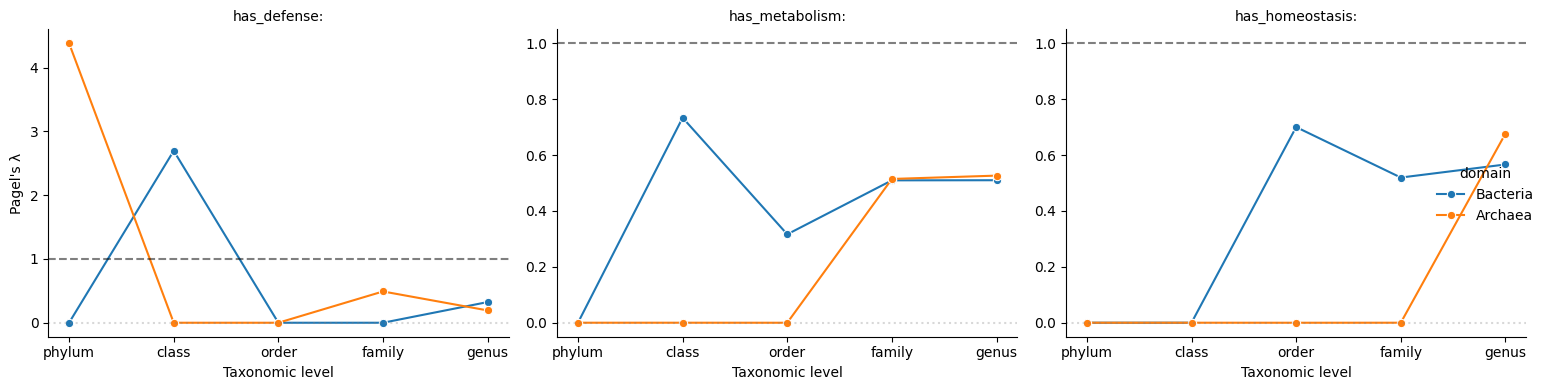

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure correct order of levels
level_order = ['phylum', 'class', 'order', 'family', 'genus', 'species']
df_lambda['level'] = pd.Categorical(df_lambda['level'], categories=level_order, ordered=True)

# Create FacetGrid
g = sns.FacetGrid(df_lambda, col='trait', hue='domain', sharey=False, height=4, aspect=1.2)
g.map(sns.lineplot, 'level', 'lambda', marker='o')
g.add_legend()
g.set_axis_labels("Taxonomic level", "Pagel's λ")
g.set_titles(col_template='{col_name}')
for ax in g.axes.flat:
    ax.axhline(y=1, color='black', linestyle='--', alpha=0.5)
    ax.axhline(y=0, color='gray', linestyle=':', alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'lambda_comparison_Bac_Arc.png', dpi=300)
plt.show()

In [20]:
summary = df_lambda.pivot_table(index=['domain', 'level'], columns='trait', values='lambda')
summary.to_csv(OUTPUT_DIR / 'lambda_summary_table.csv')
print(summary.round(4))

trait            has_defense:  has_homeostasis:  has_metabolism:
domain   level                                                  
Archaea  phylum        4.3792            0.0001           0.0001
         class         0.0001            0.0001           0.0001
         order         0.0000            0.0000           0.0000
         family        0.4904            0.0001           0.5146
         genus         0.1931            0.6767           0.5265
Bacteria phylum        0.0001            0.0001           0.0001
         class         2.6944            0.0001           0.7336
         order         0.0000            0.7002           0.3165
         family        0.0001            0.5196           0.5096
         genus         0.3242            0.5664           0.5100


In [24]:
RSCRIPT_PATH = Path('/home/hmacgregor/r_env/bin/Rscript')

# Helper: run Pagel's λ via R piped to stdin
def run_pagel_lambda_pipe(tree_path, trait_file, level, domain, subsample_threshold=500, timeout=600):
    df_traits = pd.read_csv(trait_file)
    n_taxa = df_traits['taxon'].nunique()
    if n_taxa < 3:
        print(f"Skip {domain} {level}: only {n_taxa} taxa")
        return None

    subsample = (n_taxa > subsample_threshold)

    r_script = f"""
    options(error = function() {{ traceback(2); q(save="no") }})
    if (!require("ape", quietly = TRUE)) {{
        install.packages("ape", repos = "https://cloud.r-project.org", quiet = TRUE)
    }}
    if (!require("phytools", quietly = TRUE)) {{
        install.packages("phytools", repos = "https://cloud.r-project.org", quiet = TRUE)
    }}
    library(ape); library(phytools)

    full_tree <- read.tree("{tree_path}")
    traits <- read.csv("{trait_file}")
    rownames(traits) <- traits$accession
    traits <- traits[rownames(traits) %in% full_tree$tip.label, ]

    if (nrow(traits) < 3) {{ cat("Too few taxa\\n"); q(save="no") }}

    if ("{level}" == "species") {{
        if ({str(subsample).lower()}) {{
            set.seed(42)
            keep <- sample(rownames(traits), min({subsample_threshold}, nrow(traits)))
            traits <- traits[keep, ]
        }}
        tree_use <- keep.tip(full_tree, rownames(traits))
        trait_vecs <- list()
        for (tc in c("has_defense","has_metabolism","has_homeostasis")) {{
            trait_vecs[[tc]] <- setNames(traits[[tc]], rownames(traits))
        }}
    }} else {{
        taxon_to_acc <- tapply(traits$accession, traits$taxon, function(x) sample(x,1))
        rep_accs <- unlist(taxon_to_acc)
        rep_accs <- rep_accs[rep_accs %in% full_tree$tip.label]
        if (length(rep_accs) < 3) {{ cat("Too few taxa\\n"); q(save="no") }}
        tree_use <- keep.tip(full_tree, rep_accs)
        tree_use$tip.label <- names(rep_accs)
        agg <- aggregate(traits[,c("has_defense","has_metabolism","has_homeostasis")],
                         by=list(taxon=traits$taxon), FUN=mean)
        rownames(agg) <- agg$taxon
        agg <- agg[rownames(agg) %in% tree_use$tip.label, ]
        trait_vecs <- list()
        for (tc in c("has_defense","has_metabolism","has_homeostasis")) {{
            trait_vecs[[tc]] <- setNames(agg[[tc]], rownames(agg))
        }}
    }}

    if (!is.ultrametric(tree_use)) {{
        tree_use <- force.ultrametric(tree_use, method="extend")
    }}

    for (tc in names(trait_vecs)) {{
        tv <- trait_vecs[[tc]]
        if (length(unique(tv)) < 2) next
        sig <- phylosig(tree_use, tv, method="lambda", test=TRUE)
        cat(paste0("{domain} {level} ", tc, ": lambda=", round(sig$lambda, 4), ", p=", format(sig$P, scientific=TRUE), "\\n"))
    }}
    """
    result = subprocess.run(
        [str(RSCRIPT_PATH), '-'],
        input=r_script,
        capture_output=True,
        text=True,
        timeout=timeout
    )
    if result.returncode != 0:
        print(f"Error in {domain} {level}: {result.stderr[:500]}")
    return result.stdout


# Helper: run a level within a group 
def run_level_within_group(group_column, level_column, group_name,
                           species_df, tree_path, min_taxa=5,
                           subsample_threshold=1000, timeout=600):
    results = []
    groups = species_df[group_column].dropna().unique()
    for grp in groups:
        grp_traits = species_df[species_df[group_column] == grp].copy()
        n_taxa = grp_traits[level_column].nunique()
        if n_taxa < min_taxa:
            continue

        out = grp_traits[['rep_acc', 'has_defense', 'has_metabolism', 'has_homeostasis', level_column]].copy()
        out.rename(columns={'rep_acc': 'accession', level_column: 'taxon'}, inplace=True)
        out = out[out['taxon'].notna()]
        trait_file = OUTPUT_DIR / f"traits_{group_name}_{grp}_{level_column}.csv"
        out.to_csv(trait_file, index=False)

        # For species level, we may subsample per genus
        if level_column == 'gtdb_species':
            subsample_threshold_local = 500  # subsample if genus has >500 species
        else:
            subsample_threshold_local = 1000

        print(f"Running {level_column}-within-{group_name} for {grp} ({n_taxa} taxa)")
        out_text = run_pagel_lambda_pipe(
            str(tree_path),
            trait_file,
            level_column,
            domain=f"{grp} ({group_name})",
            subsample_threshold=subsample_threshold_local,
            timeout=timeout
        )
        if out_text:
            for line in out_text.splitlines():
                if 'lambda=' not in line:
                    continue
                try:
                    trait_match = re.search(r'\b(has_defense|has_metabolism|has_homeostasis)\b', line)
                    lambda_match = re.search(r'lambda=([\deE.+-]+)', line)
                    p_match = re.search(r'p=([\deE.+-]+)', line)
                    if trait_match and lambda_match and p_match:
                        results.append({
                            'group': grp,
                            'level': level_column,
                            'trait': trait_match.group(1),
                            'lambda': float(lambda_match.group(1)),
                            'p_value': float(p_match.group(1))
                        })
                except Exception as e:
                    print(f"Error parsing line: {line}\n  {e}")
        else:
            print(f"Warning: No output for {grp}")
    return pd.DataFrame(results)

In [25]:
print("Defining bacteria_traits from species_traits...")
bacteria_traits = species_traits[species_traits['rep_acc'].isin(bac_tips)].copy()

# Define nested level combinations
nested_combos = [
    ('gtdb_phylum', 'gtdb_class', 'phylum'),
    ('gtdb_class', 'gtdb_order', 'class'),
    ('gtdb_order', 'gtdb_family', 'order'),
    ('gtdb_family', 'gtdb_genus', 'family'),
    ('gtdb_genus', 'gtdb_species', 'genus')
]

nested_results = {}
for group_col, level_col, group_name in nested_combos:
    print(f"\n=== Running {level_col}-within-{group_name} ===\n")
    df = run_level_within_group(
        group_column=group_col,
        level_column=level_col,
        group_name=group_name,
        species_df=bacteria_traits,
        tree_path=GTDB_DIR / 'gtdb_bac120_r214.tree',
        min_taxa=5,
        subsample_threshold=1000,
        timeout=600
    )
    nested_results[level_col] = df
    if not df.empty:
        df.to_csv(OUTPUT_DIR / f'{level_col}_within_{group_name}_lambda.csv', index=False)

Defining bacteria_traits from species_traits...



=== Running gtdb_class-within-phylum ===

Running gtdb_class-within-phylum for Desulfobacterota (14 taxa)


Running gtdb_class-within-phylum for Patescibacteria (16 taxa)


Running gtdb_class-within-phylum for Bacteroidota (8 taxa)


Running gtdb_class-within-phylum for Bacillota_G (5 taxa)


...

Running gtdb_species-within-genus for Xenorhabdus (18 taxa)


Running gtdb_species-within-genus for Yersinia (23 taxa)


Running gtdb_species-within-genus for Yoonia (9 taxa)


Running gtdb_species-within-genus for Zag111 (7 taxa)


Running gtdb_species-within-genus for Zeimonas (5 taxa)


In [29]:
# Summarise and compare with global λ
global_vals = df_lambda[df_lambda['domain']=='Bacteria']
global_vals['trait'] = global_vals['trait'].str.rstrip(':')
global_vals = global_vals.set_index(['level', 'trait'])['lambda']

comparison = []
for level_col, df in nested_results.items():
    if df.empty:
        continue
    medians = df.groupby('trait')['lambda'].median().to_dict()
    # Remove 'gtdb_' prefix to match global level names
    global_level = level_col.replace('gtdb_', '')
    for trait, med in medians.items():
        global_lambda = global_vals.get((global_level, trait), float('nan'))
        comparison.append({
            'level': level_col,
            'trait': trait,
            'global_lambda': global_lambda,
            'median_within_group': med,
            'n_groups': df['group'].nunique()
        })

comparison_df = pd.DataFrame(comparison)
print("\n=== Comparison: Global λ vs Median within-group λ ===\n")
print(comparison_df.round(4))


=== Comparison: Global λ vs Median within-group λ ===

           level            trait  global_lambda  median_within_group  \
0     gtdb_class      has_defense         2.6944               0.8197   
1     gtdb_class  has_homeostasis         0.0001               2.1056   
2     gtdb_class   has_metabolism         0.7336               0.0001   
3     gtdb_order      has_defense         0.0000               0.0001   
4     gtdb_order  has_homeostasis         0.7002               0.0001   
5     gtdb_order   has_metabolism         0.3165               0.0001   
6    gtdb_family      has_defense         0.0001               2.6801   
7    gtdb_family  has_homeostasis         0.5196               0.0001   
8    gtdb_family   has_metabolism         0.5096               0.0001   
9     gtdb_genus      has_defense         0.3242               1.3466   
10    gtdb_genus  has_homeostasis         0.5664               1.4441   
11    gtdb_genus   has_metabolism         0.5100               0.000

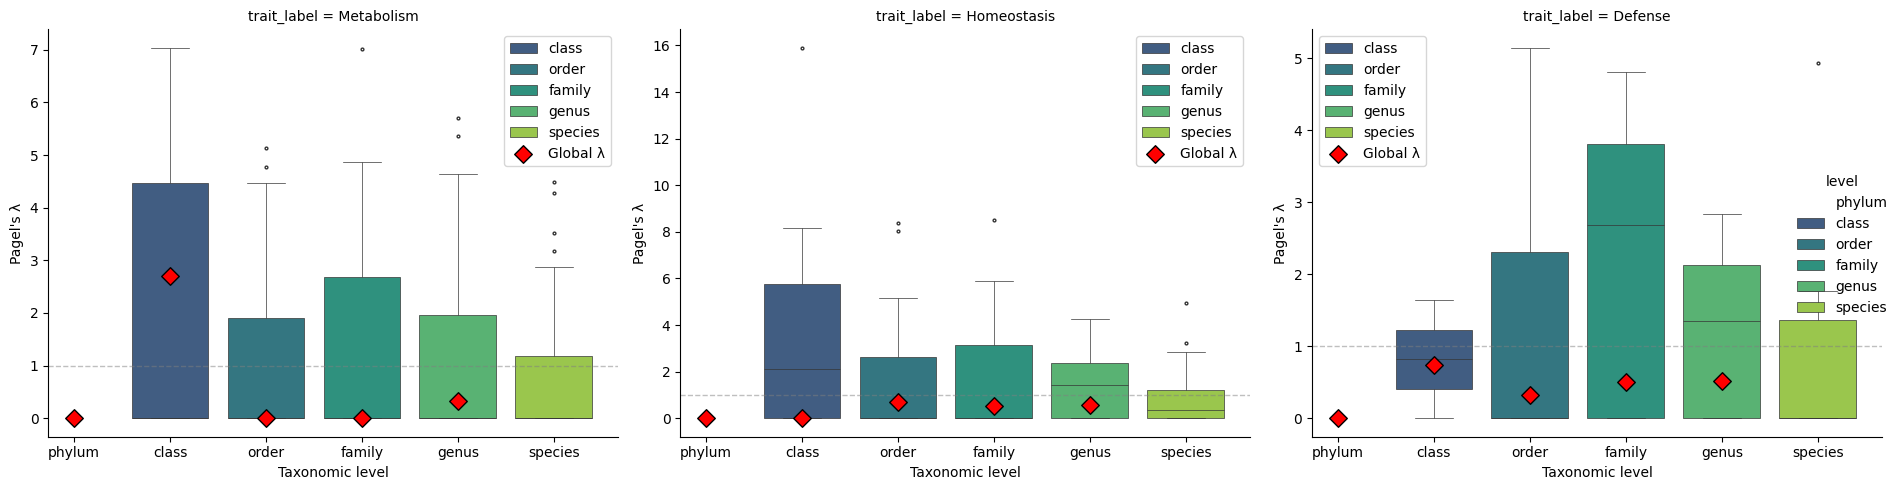

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Ensure we have the nested results data
# (assuming nested_results dictionary is already populated)
# We'll combine all nested results into one DataFrame for plotting
all_nested = []
for level_col, df in nested_results.items():
    if df.empty:
        continue
    df = df.copy()
    df['level'] = level_col.replace('gtdb_', '')  # clean level names
    all_nested.append(df)
nested_combined = pd.concat(all_nested, ignore_index=True)

# Map trait names to nicer labels
trait_labels = {
    'has_defense': 'Defense',
    'has_metabolism': 'Metabolism',
    'has_homeostasis': 'Homeostasis'
}
nested_combined['trait_label'] = nested_combined['trait'].map(trait_labels)

# Ensure correct order of levels
level_order = ['phylum', 'class', 'order', 'family', 'genus', 'species']
nested_combined['level'] = pd.Categorical(nested_combined['level'], categories=level_order, ordered=True)

# Get global λ values (remove trailing colon, map to levels)
global_df = df_lambda[df_lambda['domain']=='Bacteria'].copy()
global_df['trait'] = global_df['trait'].str.rstrip(':')
global_df['level'] = global_df['level'].str.replace('gtdb_', '')
global_df = global_df[global_df['level'].isin(level_order)]

# Create figure: one row per trait, one column per level? 
# Better: facet by trait, boxplot of λ across levels, with global overlaid.
g = sns.FacetGrid(nested_combined, col='trait_label', hue='level', 
                  sharey=False, height=5, aspect=1.2)
g.map_dataframe(sns.boxplot, x='level', y='lambda', order=level_order, 
                palette='viridis', fliersize=2, linewidth=0.5)
g.add_legend()

# Overlay global λ as points on each facet
for ax, (trait_label, grp) in zip(g.axes.flat, nested_combined.groupby('trait_label')):
    trait_orig = {v: k for k, v in trait_labels.items()}[trait_label]
    global_vals = global_df[global_df['trait'] == trait_orig]
    # Plot global points with a distinct style
    for _, row in global_vals.iterrows():
        level = row['level']
        if level not in level_order:
            continue
        lam = row['lambda']
        # Find x position for this level (boxplot positions are 0,1,2,...)
        x_pos = level_order.index(level)
        ax.scatter(x_pos, lam, color='red', s=80, zorder=10, 
                   marker='D', edgecolor='black', label='Global λ' if x_pos==0 else "")
    ax.axhline(1, color='gray', linestyle='--', alpha=0.5, linewidth=1)
    ax.set_ylabel('Pagel\'s λ')
    ax.set_xlabel('Taxonomic level')
    # Remove duplicate legend entries
    handles, labels = ax.get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    ax.legend(by_label.values(), by_label.keys())

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'nested_lambda_boxplot_global_overlay.png', dpi=300)
plt.show()

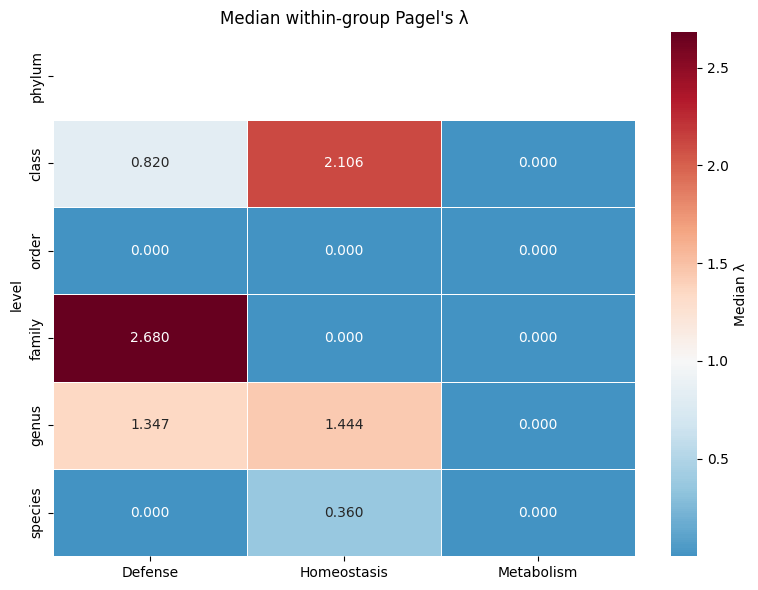

In [32]:
# Pivot table of median within-group λ
heatmap_data = nested_combined.groupby(['level', 'trait'])['lambda'].median().unstack()
heatmap_data = heatmap_data.reindex(level_order)
heatmap_data.columns = [trait_labels.get(c, c) for c in heatmap_data.columns]

plt.figure(figsize=(8, 6))
sns.heatmap(heatmap_data, annot=True, fmt='.3f', cmap='RdBu_r', center=1,
            linewidths=0.5, cbar_kws={'label': 'Median λ'})
plt.title('Median within-group Pagel\'s λ')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'nested_lambda_heatmap.png', dpi=300)
plt.show()

In [ ]:
# ------------------------------------------------------------------
# 6. Clean up temporary CSV files (optional)
# ------------------------------------------------------------------
# for f in OUTPUT_DIR.glob('traits_*.csv'):
#     f.unlink()

## Section 5 — Dual-Specialist Scatter

Scatter plot of defense vs metabolism gene counts, colored by phylum.

In [ ]:
fig, ax = plt.subplots(figsize=(10, 8))

phylum_colors = {
    'Actinomycetota': '#e74c3c',
    'Pseudomonadota': '#3498db',
    'Bacillota': '#2ecc71',
    'Chloroflexota': '#f39c12',
    'Bacteroidota': '#9b59b6',
    'Cyanobacteriota': '#1abc9c'
}

for phylum in MAJOR_PHYLA:
    phylum_data = genome_counts[genome_counts['phylum'] == phylum]
    ax.scatter(phylum_data['n_defense'], phylum_data['n_metabolism'],
              label=phylum, alpha=0.6, s=30,
              color=phylum_colors.get(phylum, '#95a5a6'))

# Mark 75th percentile thresholds
p75_def = genome_counts['n_defense'].quantile(0.75)
p75_met = genome_counts['n_metabolism'].quantile(0.75)

ax.axvline(x=p75_def, color='gray', linestyle='--', alpha=0.5, label=f'75th %ile defense')
ax.axhline(y=p75_met, color='gray', linestyle='--', alpha=0.5, label=f'75th %ile metabolism')

# Count dual specialists (both > 75th percentile)
dual_spec = ((genome_counts['n_defense'] > p75_def) & (genome_counts['n_metabolism'] > p75_met)).sum()

ax.set_xlabel('Defense Gene Count')
ax.set_ylabel('Metabolism Gene Count')
ax.set_title('Dual-Specialist Genomes')
ax.legend(loc='upper right', fontsize=9)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(FIG_DIR / "nb03_dual_specialist_scatter.png", dpi=300, bbox_inches='tight')
plt.show()

print(f"Dual specialists (both > 75th percentile): {dual_spec}")
print(f"Total genomes: {len(genome_counts)}")
print(f"Figure saved: nb03_dual_specialist_scatter.png")

In [ ]:
# Broad co-occurrence breakdown (H3 — any-gene threshold, not 75th-pct)
n_total = len(genome_counts)
both_any     = ((genome_counts['n_defense'] > 0) & (genome_counts['n_metabolism'] > 0)).sum()
defense_only = ((genome_counts['n_defense'] > 0) & (genome_counts['n_metabolism'] == 0)).sum()
metab_only   = ((genome_counts['n_defense'] == 0) & (genome_counts['n_metabolism'] > 0)).sum()
neither      = ((genome_counts['n_defense'] == 0) & (genome_counts['n_metabolism'] == 0)).sum()

print("Broad co-occurrence (n_defense > 0 AND n_metabolism > 0):")
print(f"  Both classes:      {both_any:,}  ({both_any/n_total*100:.1f}%)")
print(f"  Defense only:      {defense_only:,}  ({defense_only/n_total*100:.1f}%)")
print(f"  Metabolism only:   {metab_only:,}  ({metab_only/n_total*100:.1f}%)")
print(f"  Neither:           {neither:,}  ({neither/n_total*100:.1f}%)")
print(f"  Sum check:         {both_any + defense_only + metab_only + neither:,} (should be {n_total:,})")